# `mu_to_H0` — Second-to-Third Rung Distance Ladder Demo

This notebook demonstrates how to use `mu_to_H0.py` to measure H0 from Cepheid distance moduli to calibrator SN host galaxies.

**Concept:**  
The full SH0ES distance ladder runs Cepheids → calibrator SNe → Hubble-flow SNe.  
`mu_to_H0` takes the second rung as a *user input* (Cepheid distance moduli μ to each host) and fits the third rung (Hubble-flow SNe) to recover H0 and M_B, using the full SN covariance matrix.

**Required files** (produced by `prep_truncated_data.py`):
- `truncated_y.npy` — SN magnitude observables (352 rows)
- `truncated_C.npy` — SN covariance matrix (352 × 352)
- `truncated_labels.csv` — row metadata (label, type, host)

## 1. Load SH0ES second and third rung data

In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mu_to_H0 import solve_H0

y      = np.load('data/truncated_y.npy')
C      = np.load('data/truncated_C.npy')
labels = pd.read_csv('data/truncated_labels.csv')

cal = labels[labels['type'] == 'std_cal']
hf  = labels[labels['type'] == 'std_hf']

In [ ]:
# merge with Pantheon+ data -- this is purely for plotting purposes for now
pplus = pd.read_csv('Pantheon+SH0ES.dat', sep=r'\s+', comment='#')
pplus['key'] = pplus['CID'].astype(str) + '_' + pplus['IDSURVEY'].astype(str)

# extract SN name from y-labels
for i in labels.index.values:
    label = labels.loc[i,'label']
    if type(label) != str:
        continue
    if '_' in label:
        ylabel_split = label.split('_')
        
        if len(ylabel_split) == 2:
            labels.loc[i,'CID'] = ylabel_split[0]
            labels.loc[i,'IDSURVEY'] = ylabel_split[1]
        elif len(ylabel_split) == 3:
            labels.loc[i,'calib_host'] = ylabel_split[0]
            labels.loc[i,'CID'] = ylabel_split[1]
            labels.loc[i,'IDSURVEY'] = ylabel_split[2]
labels[labels['CID'].notna()]

labels['key'] = labels['CID'].astype(str) + '_' + labels['IDSURVEY']
merged = pd.merge(pplus[['CID','zHD','zHEL','zCMB','m_b_corr','m_b_corr_err_DIAG','MU_SH0ES','key']], labels[['key','host']], on='key', how='inner')

In [93]:
merged

,CID,zHD,zHEL,zCMB,m_b_corr,m_b_corr_err_DIAG,MU_SH0ES,key,host
0,2011fe,0.00122,0.00082,0.00122,9.74571,1.516210,28.9987,2011fe_51,m101
1,2011fe,0.00122,0.00082,0.00122,9.80286,1.517230,29.0559,2011fe_56,m101
2,2012cg,0.00256,0.00144,0.00256,11.47030,0.781906,30.7233,2012cg_51,n4424
3,2012cg,0.00256,0.00144,0.00256,11.49190,0.798612,30.7449,2012cg_56,n4424
4,1981B,0.00317,0.00236,0.00350,11.54160,0.613941,30.7946,1981B_50,n4536
...,...,...,...,...,...,...,...,...,...
347,8921,0.14423,0.14539,0.14410,19.76300,0.239442,39.0160,8921_1,NaN
348,13796,0.14747,0.14870,0.14729,19.71420,0.169668,38.9672,13796_1,NaN
349,14024,0.14771,0.14881,0.14759,19.88100,0.186845,39.1340,14024_1,NaN
350,180166,0.14778,0.14750,0.14757,19.90800,0.168022,39.1610,180166_15,NaN


# What's in ```y``` (observable) vector?

## Hubble's law:
$$ 
\begin{cases}
H_0 \equiv v [\mathrm{km/s}] \cdot d^{-1} [\mathrm{Mpc}] & \\
\mu \equiv m - M = 5\log_{10}\frac{d}{10} \\
z \approx v/c & (z\ll 1; \text{see, e.g., Visser 2004 for higher order terms})
\end{cases}
$$

$$ H_0 = (cz) \cdot \left(10^{-6} \cdot 10 \cdot \frac{d [\mathrm{pc}]}{10 [\mathrm{pc}]}\right)^{-1}$$

$$\log_{10} H_0 = \log_{10}(cz) - \log_{10}\left(\frac{d}{10}\right) + 5$$

$$\log_{10} H_0 = \log_{10}(cz) - \frac{\mu}{5} + 5$$

$$5\log_{10} H_0 = 5\log_{10}(cz) - \left(m - M\right) + 25$$

## 2. Provide Cepheid distance moduli

The dictionary `mu_host` maps each host galaxy name to its Cepheid distance modulus (magnitudes).  
**Replace the values below with your own Cepheid measurements.**

The demo values are taken from Table 6 in Riess et al.

In [121]:
mu_host_unique = [
    29.178, 32.920, 34.527, 32.830, 33.709, 32.563, 32.541, 31.378,
    31.287, 31.491, 31.450, 32.051, 32.612, 32.464, 33.014, 32.331,
    32.120, 31.936, 32.804, 31.635, 31.722, 31.603, 30.844, 30.835,
    31.812, 32.599, 33.116, 31.772, 30.546, 33.094, 32.223, 32.363,
    31.628, 33.246, 32.500, 33.187, 32.848
]


Host_unique = [
    "M101", "M1337", "N105A", "N0691", "N976A", "N1015", "N1309", "N1365",
    "N1448", "N1559", "N2442", "N2525", "N2608", "N3021", "N3147", "N3254",
    "N3370", "N3447", "N3583", "N3972", "N3982", "N4038", "N4424", "N4536",
    "N4639", "N4680", "N5468", "N5584", "N5643", "N5728", "N5861", "N5917",
    "N7250", "N7329", "N7541", "N7678", "U9391"
]
mu_host = {host.lower(): mu for host, mu in zip(Host_unique, mu_host_unique)}

In [130]:
# modify distance to any of the hosts
mu_host['n5584'] = mu_host['n5584'] + 0.1
mu_host['n3370'] = mu_host['n3370'] - 0.2

## 3. Solve for H0

In [131]:
result = solve_H0(mu_host, y=y, C=C, labels=labels)

M_B       = -19.2522 ± 0.0162  mag
H0        = 73.0477 ± 0.6029  km/s/Mpc
chi2/dof  = 334.4/350 = 0.955


## 4. Hubble diagram

Plot the calibrator and Hubble-flow SNe as a Hubble diagram, overlaying the best-fit line.

In [132]:
c = 299792.458 # speed of light in km/s

def q0_jerk_correction(z,q0,j0):
    return 0.5*(1 - q0)*z - (1/6)*(1 - q0 - 3*q0**2 + j0)*z**2

<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\m'
/var/folders/hf/dh49zz3n1x5d1p_b4qn8g4z00000gn/T/ipykernel_41597/2439495313.py:22: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('$\mu_{\\mathrm{host}}$ (input, mag)', fontsize=12)
/var/folders/hf/dh49zz3n1x5d1p_b4qn8g4z00000gn/T/ipykernel_41597/2439495313.py:23: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('$\mu_{\\mathrm{SN}}$ = $m_B$ − $M_B$  (mag)', fontsize=12)
/var/folders/hf/dh49zz3n1x5d1p_b4qn8g4z00000gn/T/ipykernel_41597/2439495313.py:38: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_xlabel('$\mu_{\\mathrm{SN}}$ = $m_B$ − $M_B$  (mag)', fontsize=12)


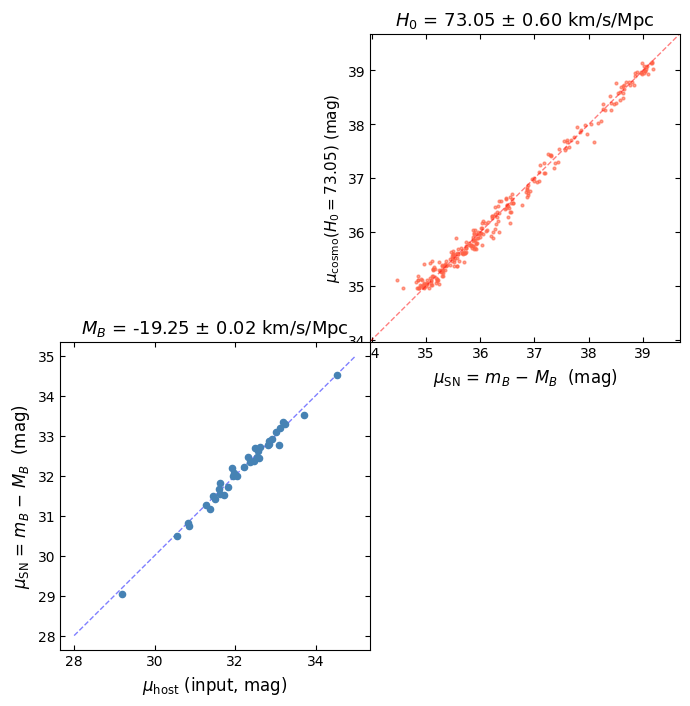

In [137]:
from scipy import linalg
from astropy.cosmology import LambdaCDM
cosmo = LambdaCDM(H0=result['H0'], Om0=0.3, Ode0=0.7)

fig, axes = plt.subplots(2, 2, figsize=(8,8))
plt.subplots_adjust(wspace=0,hspace=0)
axes[1,1].axis('off')
axes[0,0].axis('off')

# ── μ_SN vs μ_Cepheid (per host mean) ─────────────────────────
ax = axes[1,0]

cal_mu     = y[cal.index] - M_B
hosts_list = labels['host'].dropna().unique()#calibrator_hosts(labels)
x_vals = [mu_host[h] for h in hosts_list]
y_vals = [cal_mu[labels[labels['host'] == h].index].mean() for h in hosts_list]

ax.scatter(x_vals, y_vals, s=20, color='steelblue', zorder=3,
           label='Calibrators (per-host mean)')
mu_range = np.linspace(28, 35, 100)
ax.plot(mu_range, mu_range, 'b--', lw=1, alpha=0.5, label='1:1 (perfect calibration)')
ax.set_xlabel('$\mu_{\\mathrm{host}}$ (input, mag)', fontsize=12)
ax.set_ylabel('$\mu_{\\mathrm{SN}}$ = $m_B$ − $M_B$  (mag)', fontsize=12)
ax.set_title(fr'$M_B$ = {result["M_B"]:.2f} ± {result["sigma_M_B"]:.2f} km/s/Mpc',
             fontsize=13)

# ── z_SN vs mu_SN ───────────────────────────────────
ax2 = axes[0,1]
hf_mu = merged.loc[hf.index]['m_b_corr'] - M_B
hf_z  = merged.loc[hf.index]['zHD']
mu_range = np.linspace(hf_mu.min()-0.5, hf_mu.max()+0.5,100)
ax2.scatter(hf_mu, cosmo.distmod(hf_z), s=4, color='tomato', alpha=0.6,
            label='HF residuals')
ax2.plot(mu_range, mu_range, 'r--', lw=1, alpha=0.5)
# ax2.set_xlim(hf_mu.min()-0.5, hf_mu.max()+0.5)
ax2.set_xlim(mu_range.min(), mu_range.max())
ax2.set_ylim(mu_range.min(), mu_range.max())
ax2.set_xlabel('$\mu_{\\mathrm{SN}}$ = $m_B$ − $M_B$  (mag)', fontsize=12)
ax2.set_ylabel(rf'$\mu_{{\mathrm{{cosmo}}}} (H_0 = {result["H0"]:.2f})$ (mag)', fontsize=11)
ax2.set_title(fr'$H_0$ = {result["H0"]:.2f} ± {result["sigma_H0"]:.2f} km/s/Mpc',
             fontsize=13)
for ax in axes.flatten():
    ax.tick_params(direction='in',top=True, right=True)
plt.show()

## 6. Uniform distance-scale shift

A global bias in the Cepheid distance scale (e.g. from a zero-point error) shifts all host distances uniformly.  
This cell shows how H0 responds to a uniform shift Δμ applied to all hosts simultaneously.

The slope dH0/dΔμ ≈ −H0 × ln(10)/5 ≈ −34 km/s/Mpc per magnitude — a ~0.01 mag Cepheid zero-point error moves H0 by ~0.3 km/s/Mpc.

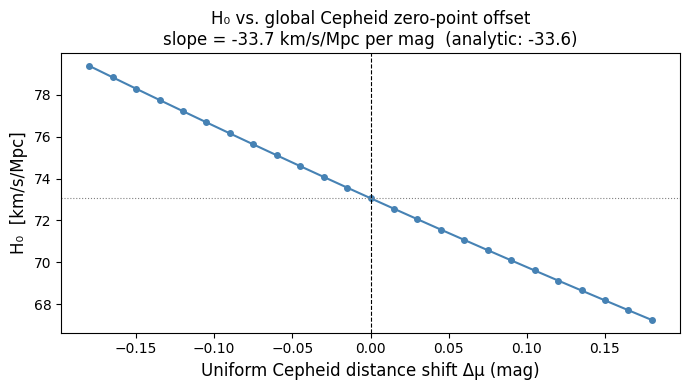

In [112]:
shifts = np.linspace(-0.18, 0.18, 25)
H0_vals = []
for ds in shifts:
    mu_shifted = {h: mu_host[h] + ds for h in mu_host}
    r = solve_H0(mu_shifted, y=y, C=C, labels=labels, verbose=False)
    H0_vals.append(r['H0'])

H0_vals = np.array(H0_vals)
slope = np.polyfit(shifts, H0_vals, 1)[0]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(shifts, H0_vals, 'o-', color='steelblue', markersize=4)
ax.axvline(0, color='k', lw=0.8, ls='--')
ax.axhline(H0_base, color='gray', lw=0.8, ls=':')
ax.set_xlabel('Uniform Cepheid distance shift Δμ (mag)', fontsize=12)
ax.set_ylabel('H₀  [km/s/Mpc]', fontsize=12)
ax.set_title(f'H₀ vs. global Cepheid zero-point offset\n'
             f'slope = {slope:.1f} km/s/Mpc per mag  '
             f'(analytic: {-H0_base * np.log(10)/5:.1f})', fontsize=12)
plt.tight_layout()
plt.show()